# MVP Análise de Dados e Boas Práticas

**Nome:** Júlia Neotti do Nascimento

**Matrícula:** (preencher)

**Dataset:** [WHO Life Expectancy](https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who/data) + [IDH](https://hdr.undp.org/data-center/documentation-and-downloads)

# Descrição do Problema

O conjunto de dados utilizado neste trabalho reúne indicadores socioeconômicos e de saúde de diferentes países, com o objetivo de analisar fatores associados à expectativa de vida da população. A base foi construída a partir da integração de indicadores de desenvolvimento humano (como o Índice de Desenvolvimento Humano – IDH e o índice de educação), indicadores de saúde (como expectativa de vida e taxas de mortalidade) e indicadores econômicos (como o Produto Interno Bruto – PIB). O objetivo deste MVP é realizar o pré-processamento e a análise exploratória desses dados, preparando a base para a aplicação futura de modelos de Machine Learning que possam explicar ou prever a expectativa de vida com base nesses indicadores.

A integração dos dados foi realizada pela variável País, considerando apenas o ano de 2013. Esse recorte temporal foi adotado com o objetivo de garantir maior consistência e qualidade entre as bases de dados utilizadas. Como as fontes apresentam diferentes níveis de disponibilidade ao longo do tempo, a seleção de um ano específico permite reduzir a presença de valores faltantes e facilitar a integração das informações. Além disso, ao focar em um único período, torna-se possível analisar de forma mais direta as relações entre os indicadores socioeconômicos e de saúde, sem a interferência de variações temporais, que não fazem parte do escopo deste trabalho.

## Hipóteses do Problema

Este estudo busca investigar as seguintes hipóteses:

1. Países com melhores indicadores educacionais tendem a apresentar maior expectativa de vida?
2. Altas taxas de mortalidade (infantil/adulta) tendem a reduzir a expectativa de vida?
3. Países com maior PIB tendem a apresentar maior expectativa de vida?


## Tipo de Problema

Este é um problema de regressão supervisionada, pois o objetivo final é prever uma variável quantitativa (expectativa de vida), a partir de um conjunto de variáveis explicativas relacionadas a indicadores socioeconômicos e de saúde, como educação, mortalidade e PIB.


## Seleção de Dados

As bases utilizadas neste estudo são públicas e muito utilizadas em análises de dados. Foram utilizadas uma base de indicadores de saúde e expectativa de vida da OMS (WHO) e uma base de indicadores de desenvolvimento humano (IDH) do UNDP. A integração dos dados foi realizada pelas variáveis País e Ano.

Na seleção do dados, apenas as váriaveis `pais`,`ano`,`status`,`exp_vida`,`mortalidade_adulta`,`mortalidade_infantil` `mortalidade_hiv`,`consumo_alcool`,`IMC`,`pib_dolar` da base "WHO Life Expectancy" foram consideradas.


## Atributos do Dataset

Após a junção, a base final contém as seguintes variáveis:

- **Identificação:** `paises`,`ano`.
- **Desenvolvimento:** `IDH`, `indice_educacao` e `anos_escolaridade_media`.
- **Economia:** `pib_dolar`.
- **Saúde:** `exp_vida`, `mortalidade_adulta`, `mortalidade_infantil`, `mortalidade_hiv`, `IMC`, `consumo_alcool`.
- **Categoria:** `status` (Desenvolvido/Em desenvolvimento).


# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento das bases de dados IDH e WHO Life Expectancy.

In [ ]:
# Importando as bibliotecas necessárias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# Carregando os dados do meu repositório do Github

idh_path = "https://raw.githubusercontent.com/julianeotti/Julia-Neotti-do-Nascimento/main/IDH.csv"
life_path = "https://raw.githubusercontent.com/julianeotti/Julia-Neotti-do-Nascimento/main/WHO_life_expectancy.csv"

IDH = pd.read_csv(idh_path, sep=";", decimal=",")
life_expect = pd.read_csv(life_path, sep=";", decimal=",")


In [ ]:
# Fazendo a verificação inicial das bases
print("IDH:", IDH.shape)
print("Life Expectancy:", life_expect.shape)

IDH.head()

IDH: (5336, 5)
Life Expectancy: (2938, 10)


,paises,ano,anos_escolaridade_media,indice_educacao,IDH
0,Afghanistan,2018,10.13892,0.447131,0.495960
1,Afghanistan,2017,10.40000,0.452222,0.493327
2,Afghanistan,2016,10.40000,0.446667,0.491278
3,Afghanistan,2015,10.40000,0.446667,0.490065
4,Afghanistan,2014,10.40000,0.443889,NaN


In [ ]:
life_expect.head()


,pais,ano,status,exp_vida,mortalidade_adulta,mortalidade_infantil,mortalidade_hiv,consumo_alcool,IMC,pib_dolar
0,Afghanistan,2015,Developing,65.0,263.0,62,0.1,0.01,19.1,584.259210
1,Afghanistan,2014,Developing,59.9,271.0,64,0.1,0.01,18.6,612.696514
2,Afghanistan,2013,Developing,59.9,268.0,66,0.1,0.01,18.1,631.744976
3,Afghanistan,2012,Developing,59.5,272.0,69,0.1,0.01,17.6,669.959000
4,Afghanistan,2011,Developing,59.2,275.0,71,0.1,0.01,17.2,63.537231


In [ ]:
# Verificando valores faltantes na base antes da junção
IDH.isnull().sum()

,0
paises,0
ano,0
anos_escolaridade_media,236
indice_educacao,236
IDH,4236


In [ ]:
# Verificando valores faltantes na base antes da junção
life_expect.isnull().sum()

,0
pais,0
ano,0
status,0
exp_vida,10
mortalidade_adulta,10
mortalidade_infantil,0
mortalidade_hiv,0
consumo_alcool,194
IMC,34
pib_dolar,448


In [ ]:
# Construção da base final (união das bases e filtro do ano de 2013)

# Filtrando o ano de 2013 nas duas bases
IDH_2013 = IDH[IDH["ano"] == 2013].copy()

life_expect_2013 = (
    life_expect
    .loc[(life_expect["ano"] == 2013) & (life_expect["status"].notna())]
    .drop(columns=["ano"])
    .copy()
)

# Fazendo a união das bases (left join): mantém todos os países e variáveis de IDH_2013 e traz as variáveis da base life_expect_2013
base2013 = IDH_2013.merge(life_expect_2013, left_on="paises", right_on="pais", how="left").drop(columns=["pais"])

print("Base 2013:", base2013.shape)

base2013.head()


Base 2013: (184, 13)


,paises,ano,anos_escolaridade_media,indice_educacao,IDH,status,exp_vida,mortalidade_adulta,mortalidade_infantil,mortalidade_hiv,consumo_alcool,IMC,pib_dolar
0,Afghanistan,2013,10.2,0.437222,0.484962,Developing,59.9,268.0,66,0.1,0.01,18.1,631.744976
1,Albania,2013,14.8,0.762778,0.781171,Developing,77.2,84.0,0,0.1,4.76,56.5,4414.723140
2,Algeria,2013,14.3,0.693333,0.745817,Developing,75.3,112.0,21,0.1,0.53,57.2,5471.866766
3,Angola,2013,10.3,0.479444,0.547266,Developing,51.1,355.0,69,2.3,8.10,22.1,484.616884
4,Antigua and Barbuda,2013,13.0,0.688889,0.767348,Developing,76.1,133.0,0,0.2,8.58,46.4,12224.864160


# Análise de Dados

Nesta etapa será melhor compreendida a estrutura do dataset, observando o número de instâncias e atributos, os tipos de variáveis e a presença de valores faltantes. Também serão exploradas as relações entre as variáveis por meio de correlações e visualizações.

O objetivo é garantir que os dados estejam adequadamente preparados para etapas posteriores de aplicação de modelos de Machine Learning.


## Total e Tipo das Instâncias

Nesta etapa, será realizada a verificação do número de instâncias presentes na base de dados e a identificação dos tipos de variáveis (numéricas e categóricas).

A partir dessa análise, observa-se que a base é composta por 184 observações e 13 variáveis, sendo 9 variáveis do tipo numérico contínuo (float64), 2 variáveis numéricas inteiras (int64) e 2 variáveis categóricas (object). Observa-se que a base possui um número relativamente reduzido de observações, o que é comum em bases reais com dados socioeconômicos e de saúde. Dessa forma, os resultados das análises devem ser interpretados com cautela, sendo este trabalho caracterizado como uma etapa inicial de análise exploratória e preparação dos dados.

Além disso, será realizada a visualização da distribuição da variável categórica status, com o objetivo de verificar a composição da base entre países desenvolvidos e em desenvolvimento.

In [ ]:
print(f"Total de instâncias (base completa 2013): {len(base2013)}")

print("\nTipos de dados da base:")
print(base2013.info())


Total de instâncias (base completa 2013): 184

Tipos de dados da base:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   paises                   184 non-null    object 
 1   ano                      184 non-null    int64  
 2   anos_escolaridade_media  180 non-null    float64
 3   indice_educacao          180 non-null    float64
 4   IDH                      183 non-null    float64
 5   status                   184 non-null    object 
 6   exp_vida                 180 non-null    float64
 7   mortalidade_adulta       180 non-null    float64
 8   mortalidade_infantil     184 non-null    int64  
 9   mortalidade_hiv          184 non-null    float64
 10  consumo_alcool           182 non-null    float64
 11  IMC                      182 non-null    float64
 12  pib_dolar                157 non-null    float64
dtypes: float6

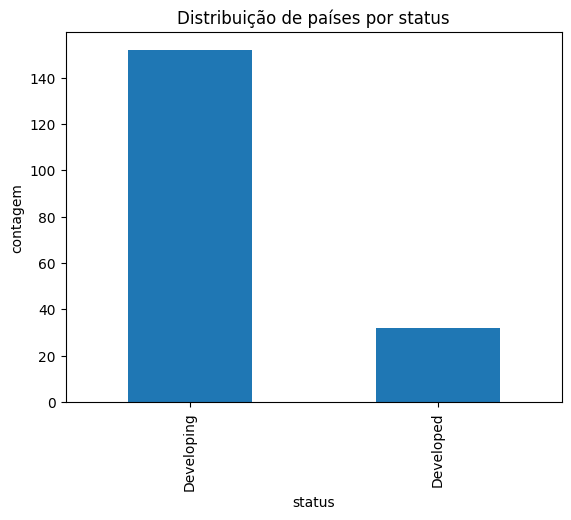

In [ ]:
# Distribuição do status (desenvolvido vs em desenvolvimento)
if "status" in base2013.columns:
    ax = base2013["status"].value_counts(dropna=False).plot(kind="bar")
    ax.set_title("Distribuição de países por status")
    ax.set_xlabel("status")
    ax.set_ylabel("contagem")
    plt.show()
else:
    print("Coluna 'status' não encontrada.")


O gráfico apresenta a distribuição dos dados entre países desenvolvidos e em desenvolvimento, evidenciando um maior número de observações para países em desenvolvimento em relação aos desenvolvidos. Isso indica um certo desequilíbrio na base, com predominância de países em desenvolvimento. Como este MVP aborda um problema de regressão, não há divisão em classes como nos modelos de classificação. Ainda assim, essa análise é importante para entender a composição da base e apoiar a interpretação dos resultados.

## Estatísticas Descritivas

Nesta seção, são apresenteadas as estatísticas descritivas, ais quais representam um resumo das principais características numéricas da base de dados. Entre as medidas analisadas estão média, desvio padrão, valores mínimo e máximo, além dos quartis, que ajudam a compreender a distribuição e a variabilidade das variáveis.

In [ ]:
# Estatísticas descritivas básicas da base
base2013.describe()

,ano,anos_escolaridade_media,indice_educacao,IDH,exp_vida,mortalidade_adulta,mortalidade_infantil,mortalidade_hiv,consumo_alcool,IMC,pib_dolar
count,184.0,180.000000,180.000000,183.000000,180.000000,180.000000,184.000000,184.000000,182.000000,182.000000,157.000000
mean,2013.0,13.027222,0.663485,0.696618,71.495556,146.855556,24.521739,0.728261,4.131429,41.601648,8266.759612
std,0.0,2.936589,0.175981,0.153835,8.280615,104.919076,89.397006,1.469235,4.188005,20.950395,16262.865632
min,2013.0,4.900000,0.223889,0.344755,49.900000,5.000000,0.000000,0.100000,0.010000,2.100000,14.214412
25%,2013.0,11.200000,0.526111,0.569774,65.975000,67.750000,0.000000,0.100000,0.010000,23.125000,676.153440
50%,2013.0,13.100000,0.691944,0.724646,73.500000,134.500000,2.000000,0.100000,3.020000,48.150000,2315.317990
75%,2013.0,14.900000,0.799583,0.811091,76.725000,218.250000,17.250000,0.400000,7.965000,59.275000,7112.335750
max,2013.0,20.400000,1.030000,0.945784,87.000000,518.000000,1000.000000,9.600000,15.040000,83.300000,113751.850000


In [ ]:
# Média das variáveis numéricas da base, exceto a variável de "ano", pois representa apenas o período dos dados
base2013.drop(columns=['ano']).describe().loc['mean'].round(2)

,mean
anos_escolaridade_media,13.03
indice_educacao,0.66
IDH,0.70
exp_vida,71.50
mortalidade_adulta,146.86
mortalidade_infantil,24.52
mortalidade_hiv,0.73
consumo_alcool,4.13
IMC,41.60
pib_dolar,8266.76


In [ ]:
# Desvio padrão das variáveis numéricas
base2013.drop(columns=['ano']).describe().loc['std']


,std
anos_escolaridade_media,2.936589
indice_educacao,0.175981
IDH,0.153835
exp_vida,8.280615
mortalidade_adulta,104.919076
mortalidade_infantil,89.397006
mortalidade_hiv,1.469235
consumo_alcool,4.188005
IMC,20.950395
pib_dolar,16262.865632


<Figure size 1200x600 with 0 Axes>

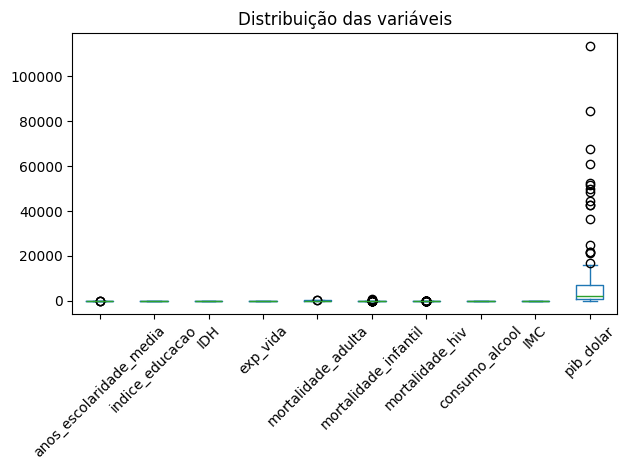

In [ ]:
# Visualização da variabilidade das variáveis numéricas (boxplot), excluindo "ano"
plt.figure(figsize=(12,6))

base2013.drop(columns=['ano']).plot(
    kind='box',
    rot=45,        # gira os nomes das variáveis, para melhorar a visualização
)

plt.title('Distribuição das variáveis')
plt.tight_layout()   # ajusta automaticamente os espaços
plt.show()

O boxplot acima permite observar a dispersão e a presença de possíveis outliers nas variáveis numéricas da base (exceto "ano", que é apenas uma variável temporal). Porém, observa-se que a variável "pib_dolar" possui valores muito maiores que as demais, dificultando a visualização da variabiliada das outras variáveis. Por isso, um segundo gráfico é apresentado excluindo o PIB, para permitir  observar com mais clareza a dispersão e possíveis outliers das demais variáveis.

<Figure size 1200x600 with 0 Axes>

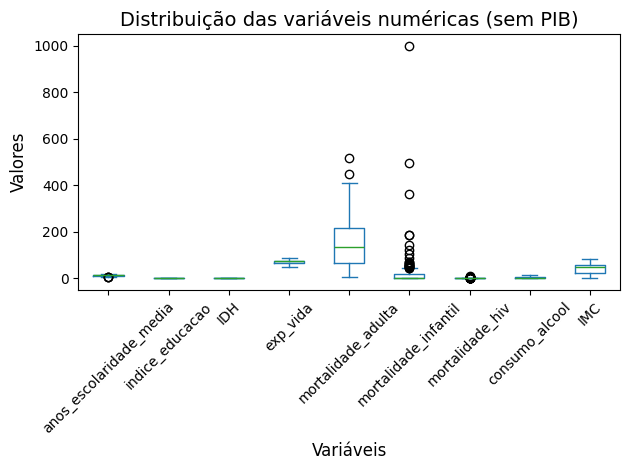

In [ ]:
#Visualização da variabilidade das variáveis numéricas, excluindo "ano" e "pib_dolar"

plt.figure(figsize=(12,6))

base2013.drop(columns=['ano','pib_dolar']).plot(
    kind='box',
    rot=45,
)

plt.title('Distribuição das variáveis numéricas (sem PIB)', fontsize=14)
plt.xlabel('Variáveis', fontsize=12)
plt.ylabel('Valores', fontsize=12)

plt.tight_layout()
plt.show()

Analisando o gráfico acima, pode-se observar que as variáveis relacionadas à mortalidade apresentam maior variabilidade entre os países, especialmente mortalidade_adulta e mortalidade_infantil, que apresentam diversos valores extremos (outliers). Já indicadores como IDH, indice_educacao e anos_escolaridade_media apresentam uma distribuição mais concentrada. A variável pib_dolar apresenta valores muito superiores às demais variáveis, além de diversos outliers, o que indica grande desigualdade econômica entre os países.

## Histogramas (distribuição de variáveis-chave)

O histograma permite visualizar a forma da distribuição dos dados, identificando possíveis assimetrias, multimodalidades e a presença de outliers.

### Expectativa de vida (`exp_vida`)

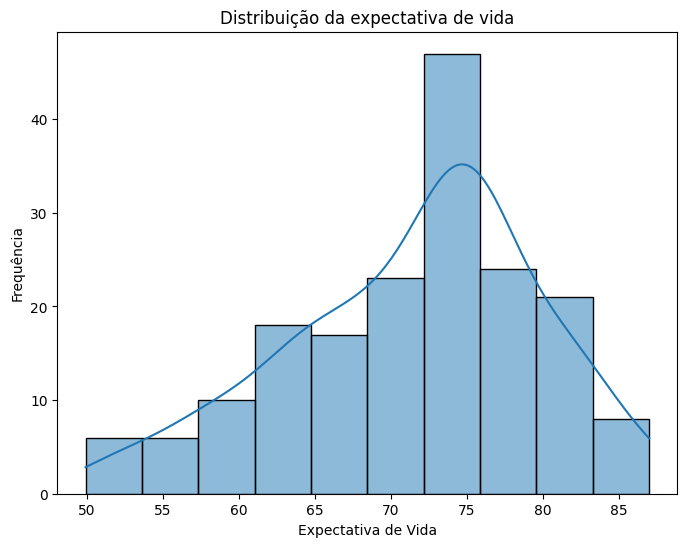

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(data=base2013, x="exp_vida", kde=True)
plt.title("Distribuição da expectativa de vida")
plt.xlabel('Expectativa de Vida')
plt.ylabel('Frequência')
plt.show()


O histograma da variável expectativa de vida apresenta uma distribuição aproximadamente simétrica e próxima de uma distribuição normal, com maior concentração de valores entre 70 e 80 anos. Observa-se que a maioria dos países possui expectativa de vida próxima desse intervalo, enquanto poucos apresentam valores muito baixos ou muito altos. Isso indica que, embora existam diferenças entre países, a expectativa de vida tende a se concentrar em uma faixa relativamente estável.

### PIB (`pib_dolar`)

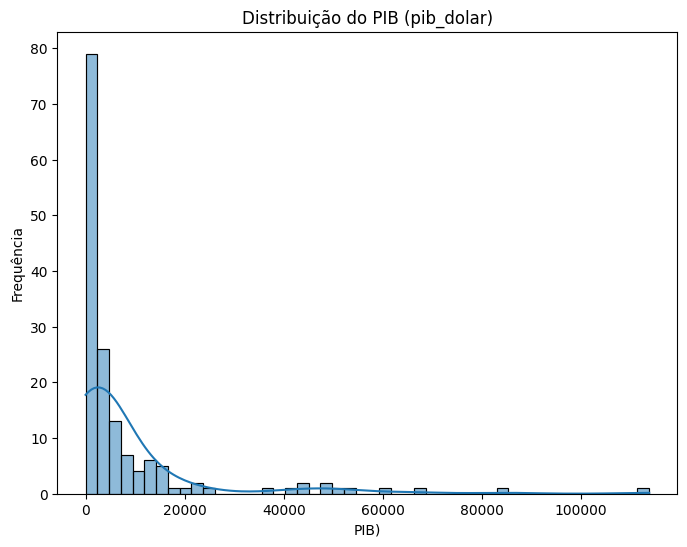

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(data=base2013, x="pib_dolar", kde=True)
plt.title("Distribuição do PIB (pib_dolar)")
plt.xlabel('PIB)')
plt.ylabel('Frequência')
plt.show()


O histograma do PIB (pib_dolar) apresenta uma distribuição fortemente assimétrica à direita. A maior parte dos países possui valores de PIB relativamente baixos, concentrados nas primeiras faixas do gráfico, enquanto poucos países apresentam valores muito elevados. Esses valores extremos indicam a presença de outliers, refletindo grandes desigualdades econômicas entre os países analisados.

## Boxplot

Para entender diferenças estruturais entre países desenvolvidos e em desenvolvimento, serão utilizados boxplots agrupados por `status`.
Isso permite comparar mediana, dispersão e outliers em indicadores como expectativa de vida, PIB e mortalidade.


In [ ]:
# Estatísticas descritivas agrupadas por Status
base2013.drop(columns=['ano']).groupby('status').describe()

anos_escolaridade_media                                            \
                             count       mean       std   min     25%    50%   
status                                                                         
Developed                     32.0  16.650000  1.675632  13.9  15.500  16.35   
Developing                   148.0  12.243919  2.536515   4.9  10.675  12.65   

                         indice_educacao            ...     IMC        \
               75%   max           count      mean  ...     75%   max   
status                                              ...                 
Developed   17.700  20.4            32.0  0.884774  ...  63.825  68.8   
Developing  13.925  17.6           148.0  0.615638  ...  57.150  83.3   

           pib_dolar                                                      \
               count          mean           std         min         25%   
status                                                                     
Developed       28.0  19930.344358  29369.629123  554.715320  2890.94249   
Developing     129.0   5735.128814  10206.308438   14.214412   535.86555   

                                                     
                    50%           75%           max  
status                                               
Developed   5431.978250  17189.301655  113751.85000  
Developing  1724.361737   6171.262444   52413.72116  

[2 rows x 80 columns]

### Expectativa de Vida por Status

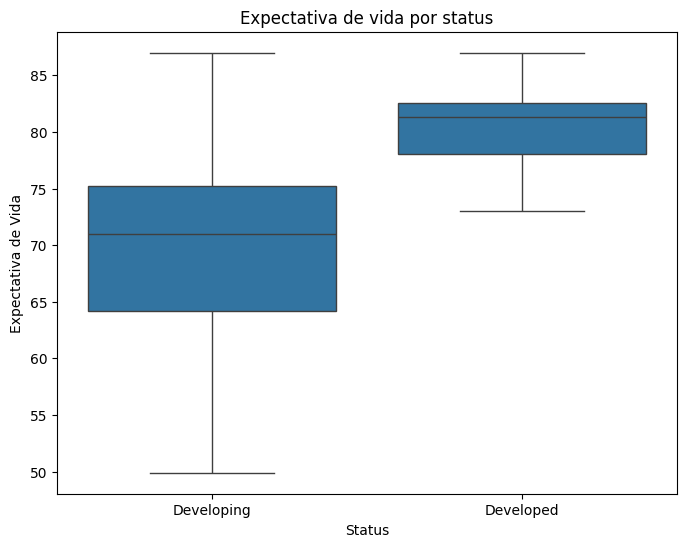

In [ ]:
# Boxplot: expectativa de vida por status
plt.figure(figsize=(8, 6))
sns.boxplot(data=base2013, x="status", y="exp_vida")
plt.title("Expectativa de vida por status")
plt.xlabel("Status")
plt.ylabel("Expectativa de Vida")
plt.show()


O boxplot mostra uma diferença clara na expectativa de vida entre países desenvolvidos e em desenvolvimento. Observa-se que países classificados como "Developed" apresentam mediana de expectativa de vida mais alta, além de uma distribuição mais concentrada em valores elevados, geralmente acima de 78 anos. Já os países com classificação "Developing" apresentam uma mediana menor e maior dispersão dos valores, com alguns países apresentando expectativa de vida significativamente mais baixa. Esse resultado sugere que o nível de desenvolvimento do país está associado a melhores condições de saúde e qualidade de vida.

### PIB por Status

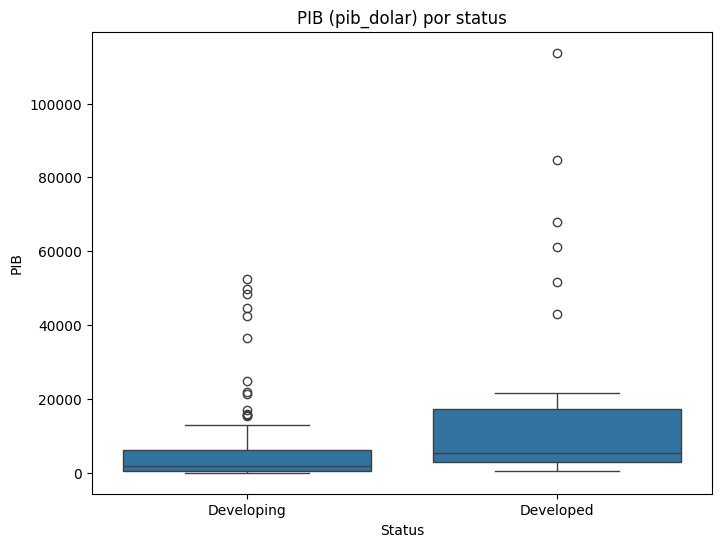

In [ ]:
# Boxplot: PIB por status (opcional para contexto econômico)
plt.figure(figsize=(8, 6))
sns.boxplot(data=base2013, x="status", y="pib_dolar")
plt.title("PIB (pib_dolar) por status")
plt.xlabel("Status")
plt.ylabel("PIB")
plt.show()


O gráfico do PIB por status também evidencia diferenças importantes entre os dois grupos. Países desenvolvidos apresentam, em geral, valores de PIB mais altos e maior dispersão, com a presença de diversos outliers representando economias muito fortes. Já os países em desenvolvimento apresentam valores de PIB mais concentrados em faixas menores, embora também existam alguns valores extremos (outliers). Essa diferença reforça a desigualdade econômica entre os grupos de países.

### Mortalidade Adulta por Status

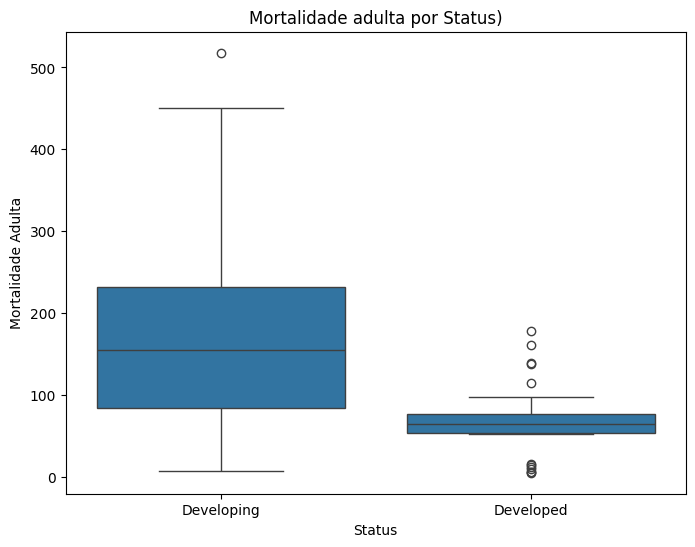

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=base2013, x="status", y="mortalidade_adulta")
plt.title("Mortalidade adulta por Status)")
plt.xlabel("Status")
plt.ylabel("Mortalidade Adulta")
plt.show()


O boxplot mostra uma diferença clara na taxa de mortalidade adulta entre países desenvolvidos e em desenvolvimento. Países classificados como em desenvolvimento apresentam valores mais altos e maior dispersão, indicando maior desigualdade nas condições de saúde. Já os países desenvolvidos apresentam taxas menores e distribuição mais concentrada, sugerindo melhores condições de saúde e qualidade de vida. De modo geral, o gráfico reforça que níveis mais altos de desenvolvimento estão associados a menores taxas de mortalidade adulta.

A comparação entre os gráficos indica que países com maior nível de desenvolvimento tendem a apresentar maior PIB, maior expectativa de vida e menores taxas de mortalidade adulta. Esse padrão sugere uma relação entre desenvolvimento econômico e melhores indicadores de saúde da população. Dessa forma, a inclusão de variáveis socioeconômicas no modelo pode contribuir para explicar variações na expectativa de vida entre os países analisados.

## Matriz de Correlação

Neste tópico, será realizada a análise de correlação entre as variáveis da base, com o objetivo de identificar possíveis relações entre elas. A variável "ano" foi novamente desconsiderada nesta etapa da análise.

Para as variáveis quantitativas, foi calculado o coeficiente de correlação, que mede o grau de associação linear entre duas variáveis. Valores próximos de 1 indicam forte correlação positiva, valores próximos de -1 indicam forte correlação negativa e valores próximos de 0 indicam ausência de correlação linear.

In [ ]:
# Matriz de correlação (apenas variáveis numéricas)
corr = base2013.drop(columns=['ano']).select_dtypes(include=[np.number]).corr()
print("\nMatriz de Correlação:")
corr



Matriz de Correlação:


,anos_escolaridade_media,indice_educacao,IDH,exp_vida,mortalidade_adulta,mortalidade_infantil,mortalidade_hiv,consumo_alcool,IMC,pib_dolar
anos_escolaridade_media,1.000000,0.958045,0.901621,0.804215,-0.563117,-0.209643,-0.415104,0.581670,0.447500,0.429640
indice_educacao,0.958045,1.000000,0.946048,0.820577,-0.558226,-0.225705,-0.420894,0.633212,0.493924,0.437313
IDH,0.901621,0.946048,1.000000,0.891231,-0.637576,-0.198971,-0.517785,0.618915,0.464676,0.469932
exp_vida,0.804215,0.820577,0.891231,1.000000,-0.721398,-0.213942,-0.647798,0.489085,0.477532,0.428082
mortalidade_adulta,-0.563117,-0.558226,-0.637576,-0.721398,1.000000,0.167778,0.704501,-0.278122,-0.384516,-0.274714
mortalidade_infantil,-0.209643,-0.225705,-0.198971,-0.213942,0.167778,1.000000,0.090384,-0.066063,-0.237195,-0.109369
mortalidade_hiv,-0.415104,-0.420894,-0.517785,-0.647798,0.704501,0.090384,1.000000,-0.166369,-0.337920,-0.177661
consumo_alcool,0.581670,0.633212,0.618915,0.489085,-0.278122,-0.066063,-0.166369,1.000000,0.274816,0.353383
IMC,0.447500,0.493924,0.464676,0.477532,-0.384516,-0.237195,-0.337920,0.274816,1.000000,0.176209
pib_dolar,0.429640,0.437313,0.469932,0.428082,-0.274714,-0.109369,-0.177661,0.353383,0.176209,1.000000


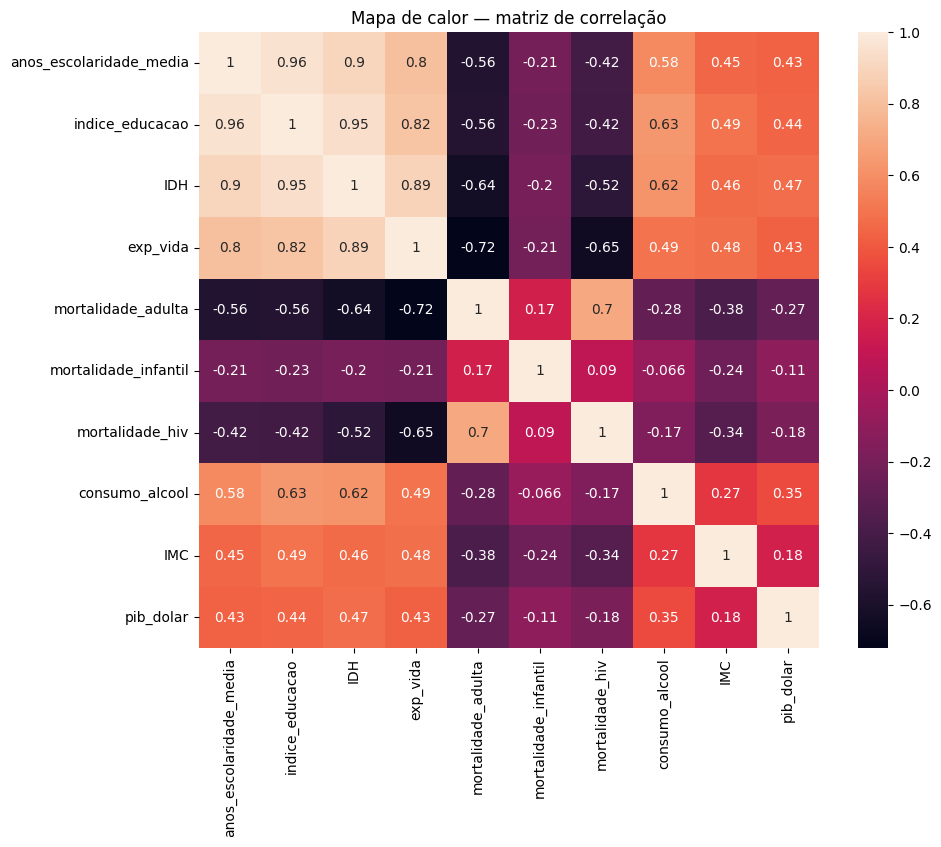

In [ ]:
# Visualização gráfica
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True)
plt.title("Mapa de calor — matriz de correlação")
plt.show()


Através da matriz de correlação, observa-se uma forte correlação positiva entre variáveis relacionadas à educação e desenvolvimento, como anos_escolaridade_media, indice_educacao e IDH, com valores próximos de 0.9. Essas variáveis também apresentam correlação positiva com a expectativa de vida, indicando que países com maiores níveis educacionais e de desenvolvimento humano tendem a apresentar maior expectativa de vida.

Por outro lado, variáveis relacionadas à mortalidade, como mortalidade_adulta e mortalidade_hiv, apresentam correlação negativa com a expectativa de vida, especialmente mortalidade_adulta (-0.72). Isso indica que maiores taxas de mortalidade estão associadas a menores níveis de expectativa de vida.

Além disso, observa-se uma correlação positiva moderada entre o PIB e variáveis de desenvolvimento, como IDH e expectativa de vida, sugerindo que melhores condições econômicas podem estar associadas a melhores indicadores sociais e de saúde.

A matriz também evidencia uma alta correlação entre algumas variáveis, como anos_escolaridade_media, indice_educacao e IDH, indicando possível multicolinearidade.

## Tratamento de Valores Nulos

Nesta etapa, é realizado o tratamento de valores faltantes presentes na base de dados, uma vez que esse tipo de ocorrência é comum em bases reais e pode impactar as análises e a modelagem.


In [ ]:
# Verificando a presença de valores nulos na base
print("Quantidade de valores faltantes:")
base2013.isnull().sum()

Quantidade de valores faltantes:


,0
paises,0
ano,0
anos_escolaridade_media,4
indice_educacao,4
IDH,1
status,0
exp_vida,4
mortalidade_adulta,4
mortalidade_infantil,0
mortalidade_hiv,0


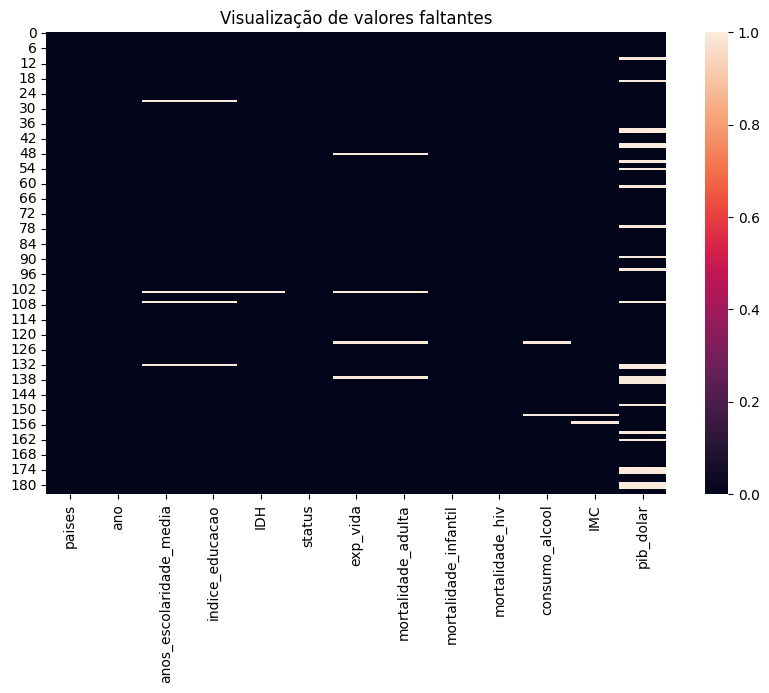

In [ ]:
# Visualizando
plt.figure(figsize=(10,6))
sns.heatmap(base2013.isnull(), cbar=True)
plt.title("Visualização de valores faltantes")
plt.show()

A análise de valores faltantes mostra que a maior parte das variáveis da base possui pouca ou nenhuma ausência de dados.

As variáveis `status`, `mortalidade_infantil` e `mortalidade_hiv` não apresentam valores faltantes (NA).

Algumas variáveis apresentam pequena quantidade de valores ausentes, como `anos_escolaridade_media`, `indice_educacao`, `exp_vida` e `mortalidade_adulta` (4 valores faltantes cada), além de `consumo_alcool` e `IMC`, que apresentam apenas 2 valores ausentes. E, a variável com maior quantidade de dados faltantes é `pib_dolar`, com 27 valores ausentes.

A visualização gráfica dos valores faltantes confirma que as ausências estão distribuídas de forma pontual ao longo da base, sem formação de padrões evidentes de concentração em determinadas linhas ou variáveis.

De forma geral, a quantidade de valores faltantes é relativamente baixa em relação ao tamanho da base, o que permite aplicar estratégias de tratamento sem comprometer significativamente a análise.

Para lidar com esses casos, foram adotadas duas estratégias principais. A primeira consiste na remoção de linhas quando o valor faltante ocorre em variáveis consideradas essenciais para a análise, como `exp_vida` e `pib_dolar`.

A segunda estratégia consiste na imputação pela média para algumas covariáveis numéricas, como `indice_educacao` e `IMC`, substituindo os valores ausentes pela média observada dessas variáveis.

In [ ]:
# Removendo as linhas com NA nas variáveis consideradas importantes no estudo
vars_interesse = ["pib_dolar", "mortalidade_adulta", "exp_vida", "consumo_alcool"]
present = [v for v in vars_interesse if v in base2013.columns]
base2013 = base2013.dropna(subset=present).copy()

# Imputando o valor da média para covariáveis numéricas com NA
for col in ["anos_escolaridade_media", "indice_educacao", "IMC"]:
    if col in base2013.columns:
        base2013[col] = base2013[col].fillna(base2013[col].mean())

# Conferindo
base2013.isna().sum().sort_values(ascending=False).head(10)


,0
paises,0
ano,0
anos_escolaridade_media,0
indice_educacao,0
IDH,0
status,0
exp_vida,0
mortalidade_adulta,0
mortalidade_infantil,0
mortalidade_hiv,0


Após a conferência, pode-se observar que não existem mais valores faltantes na base de dados.

# Pré-Processamento de Dados

Nesta etapa, os dados são organizados em variáveis explicativas (X) e variável de interesse (y). Antes dessa separação, a variável `ano` foi removida da base de dados, pois o conjunto foi filtrado apenas para o ano de 2013, fazendo com que essa variável apresentasse valor único e não agregasse informação à análise.

Além disso, na etapa de análise de correlação, foi observada uma alta correlação entre as variáveis:
 - `IDH` e `indice_educacao`,
 - `IDH` e `anos_escolaridade_media`,
 - `anos_escolaridade_media` e `indice_educacao`,
indicando que essas variáveis carregam informações muito semelhantes.

Dessa forma, optou-se pela remoção das variáveis `IDH` e `anos_escolaridade_media`, mantendo apenas `indice_educacao`. Essa escolha permite reduzir problemas de multicolinearidade e simplificar o modelo sem perda significativa de informação, uma vez que o índice de educação representa diretamente o componente educacional do desenvolvimento humano, estando relacionado tanto ao IDH quanto aos anos médios de escolaridade.

Em seguida, os dados são divididos em conjuntos de treino e teste, etapa fundamental para o desenvolvimento e avaliação de modelos de aprendizado de máquina.

In [ ]:
# Removendo a coluna 'ano'
base2013 =  base2013.drop(columns=["ano"])

In [ ]:
# Remoção das variáveis altamente correlacionadas
base2013 = base2013.drop(columns=["IDH", "anos_escolaridade_media"], errors="ignore")

In [ ]:
# Separarando features (X) e target (y)
X = base2013.drop('exp_vida', axis=1)
y = base2013['exp_vida']

In [ ]:
# Separação da base em treino (75%) e teste (25%)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.25, random_state=12345)


In [ ]:
# Vizualizando a dimensão das bases de treino e teste
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (114, 9)
Dimensões de X_test: (39, 9)
Dimensões de y_train: (114,)
Dimensões de y_test: (39,)


Além das transformações anteriores, a variável `status` foi convertida para o tipo categórico com o objetivo de garantir que fosse tratada corretamente como uma variável qualitativa. Essa transformação evita que a variável seja interpretada como numérica e facilita seu tratamento em etapas posteriores, como a etapa de modelagem.

In [ ]:
# Transformando a variável qualitativa 'status' em categórica
if "status" in X_train.columns:
    X_train["status"] = X_train["status"].astype("category")
    X_test["status"] = X_test["status"].astype("category")

## Padronização

Como as variáveis apresentam escalas bastante diferentes (por exemplo, PIB, mortalidade e índices socioeconômicos), foi aplicada padronização dos dados, garantindo que todas as variáveis contribuam de forma equilibrada para etapas posteriores de modelagem.

In [ ]:
# Mantendo apenas as variáveis numéricas
X_train_num = X_train.drop(columns=["paises"], errors="ignore").select_dtypes(include="number")
X_test_num = X_test.drop(columns=["paises"], errors="ignore").select_dtypes(include="number")

# Inicializando o StandardScaler
scaler = StandardScaler()

# Aprende média e desvio padrão apenas de X_train
scaler.fit(X_train_num)

# Ajusta no treino
X_train_num_std = scaler.transform(X_train_num)

# Aplica no teste
X_test_num_std = scaler.transform(X_test_num)

In [ ]:
# Exibir as primeiras linhas dos dados padronizados
df_std = pd.DataFrame(X_train_num_std, columns=X_train_num.columns)

print("\nPrimeiras 5 linhas dos dados padronizados (treino):")
print(df_std.head())


Primeiras 5 linhas dos dados padronizados (treino):
   indice_educacao  mortalidade_adulta  mortalidade_infantil  mortalidade_hiv  \
0        -0.151034            1.017005             -0.320464         1.719389   
1         0.972104           -1.079468             -0.352751        -0.453139   
2        -0.139054           -0.410765             -0.336607        -0.453139   
3        -0.025775           -1.178870             -0.352751        -0.392791   
4        -1.262193            0.998932             -0.126741        -0.211747   

   consumo_alcool       IMC  pib_dolar  
0        0.987436 -0.216229   0.013468  
1        2.330090  1.009021  -0.081969  
2       -0.764960  1.188788  -0.482168  
3       -1.061269 -0.476418  -0.329972  
4        0.251291  0.375108  -0.525092  


In [ ]:
# Verificando os valores da média e do desvio padrão após a padronização
media = X_train_num_std.mean()
desvio = X_train_num_std.std()

print(f"Média das variáveis após padronização: {media:.6f}")
print(f"Desvio padrão das variáveis após padronização: {desvio:.6f}")

Média das variáveis após padronização: -0.000000
Desvio padrão das variáveis após padronização: 1.000000


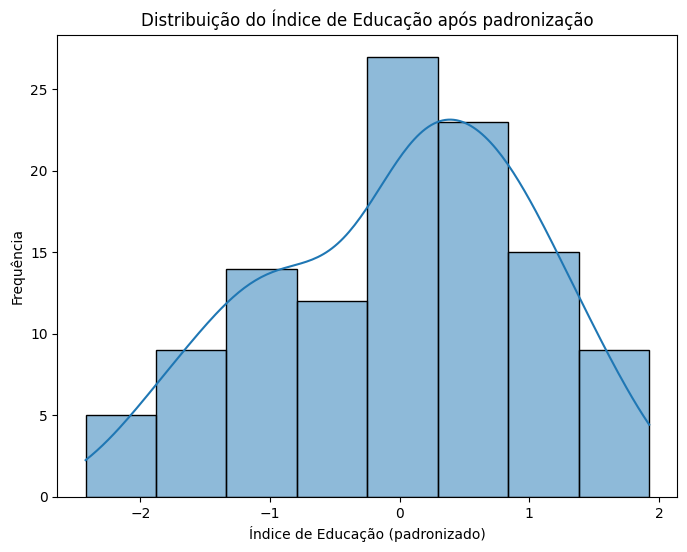

In [ ]:
# Visualização da distribuição da variável índice de educação após a padronização

plt.figure(figsize=(8,6))
sns.histplot(df_std['indice_educacao'], kde=True)

plt.title('Distribuição do Índice de Educação após padronização')
plt.xlabel('Índice de Educação (padronizado)')
plt.ylabel('Frequência')

plt.show()

Após a padronização, observa-se que as variáveis apresentam média aproximadamente igual a 0 e desvio padrão próximo de 1, indicando que o processo foi aplicado corretamente.

# Respondendo as hipóteses

A seguir, serão utilizados gráficos e estatísticas para verificar se há evidências que respondam as hipóteses propostas.


## Hipótese 1 — *Países com melhores indicadores educacionais tendem a apresentar maior expectativa de vida?*

In [ ]:
corr = base2013[['indice_educacao', 'exp_vida']].corr()
print(corr)

                 indice_educacao  exp_vida
indice_educacao         1.000000  0.814652
exp_vida                0.814652  1.000000


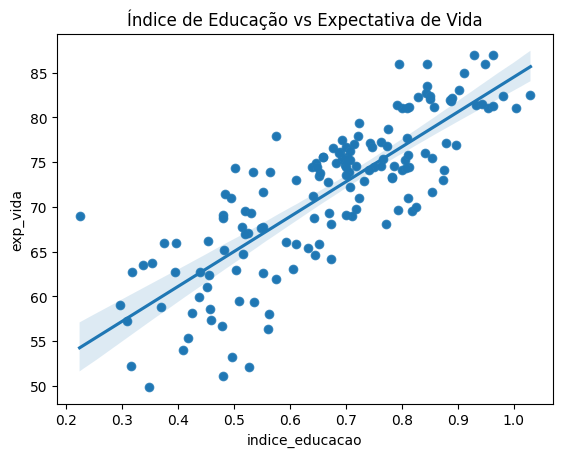

In [ ]:
# Gráfico de dispersão entre indice_educacao e exp_vida -- espera-se uma relação positiva
sns.scatterplot(data=base2013, x="indice_educacao", y="exp_vida")
sns.regplot(data=base2013, x="indice_educacao", y="exp_vida")
plt.title("Índice de Educação vs Expectativa de Vida")
plt.show()


Analisando o gráfico de dispersão acima sob a primeira hipótese, pode-se observar que existe uma relação positiva entre o índice de educação e a expectativa de vida, sugerindo que países com melhores indicadores educacionais tendem a apresentar maior longevidade. A análise de correlação reforça esse resultado, apresentando um coeficiente de aproximadamente 0,81.

## Hipótese 2 — *Altas taxas de mortalidade (infantil/adulta) tendem a reduzir a expectativa de vida?*

In [ ]:
corr = base2013[['mortalidade_adulta','exp_vida']].corr()
print(corr)

                    mortalidade_adulta  exp_vida
mortalidade_adulta            1.000000 -0.708364
exp_vida                     -0.708364  1.000000


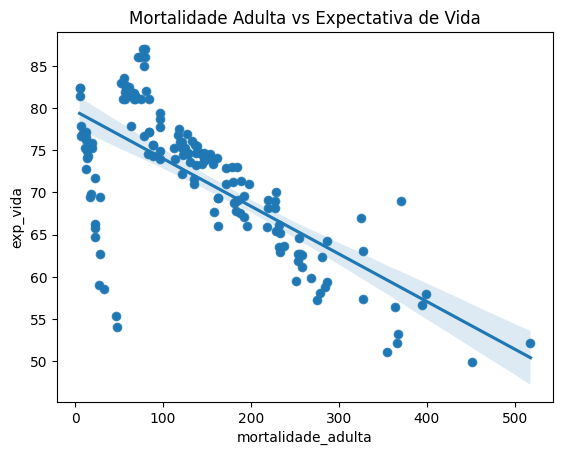

In [ ]:
# Gráfico de dispersão entre mortalidade_adulta e exp_vida -- espera-se uma relação negativa
sns.scatterplot(data=base2013, x="mortalidade_adulta", y="exp_vida")
sns.regplot(data=base2013, x="mortalidade_adulta", y="exp_vida")
plt.title("Mortalidade Adulta vs Expectativa de Vida")
plt.show()


Ao analisar o gráfico referente à segunda hipótese, observa-se uma relação inversa entre a mortalidade adulta e a expectativa de vida, indicando que países com níveis mais elevados de mortalidade tendem a apresentar menor longevidade. Esse padrão também é confirmado pela análise de correlação, que apresentou coeficiente de aproximadamente -0,70, caracterizando uma relação negativa entre essas variáveis.

## Hipótese 3 — *Países com maior PIB tendem a apresentar maior expectativa de vida?*

In [ ]:
corr = base2013[['pib_dolar', 'exp_vida']].corr()
print(corr)

           pib_dolar  exp_vida
pib_dolar   1.000000  0.427712
exp_vida    0.427712  1.000000


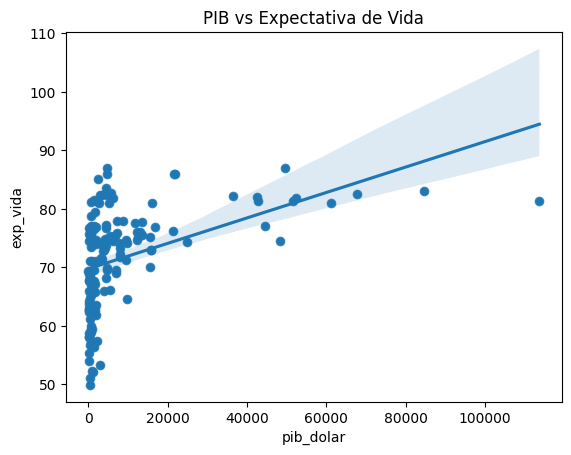

In [ ]:
# Gráfico de dispersão entre pib_dolar e exp_vida -- espera-se uma relação positiva
sns.scatterplot(data=base2013, x="pib_dolar", y="exp_vida")
sns.regplot(data=base2013, x="pib_dolar", y="exp_vida")
plt.title("PIB vs Expectativa de Vida")
plt.show()


A análise de correlação entre o PIB e a expectativa de vida apresentou um coeficiente de aproximadamente 0,43, indicando uma relação positiva moderada entre essas variáveis. Esse resultado sugere que países com maior nível de renda tendem, em média, a apresentar maior expectativa de vida. O gráfico de dispersão também mostra essa tendência positiva, embora a relação não seja perfeitamente linear, já que alguns países com PIB relativamente baixo apresentam expectativa de vida elevada. Isso indica que, apesar de o PIB estar associado à expectativa de vida, ele pode não ser o fator mais determinante quando comparado a outros indicadores analisados no estudo.

# Conclusão

Este trabalho teve como objetivo analisar a relação entre indicadores socioeconômicos e de saúde e a expectativa de vida dos países, utilizando técnicas de análise exploratória de dados e pré-processamento como etapa inicial para futuras aplicações de Machine Learning. A base utilizada foi construída a partir da integração de dados de desenvolvimento humano, indicadores de saúde e variáveis econômicas, permitindo investigar fatores associados à longevidade da população.

Além da análise exploratória, foram realizadas etapas importantes de pré-processamento dos dados, incluindo tratamento de valores faltantes, remoção de variáveis redundantes ou pouco informativas, separação entre variáveis explicativas e variável alvo, divisão da base em conjuntos de treino e teste e padronização das variáveis numéricas. Essas etapas garantem que os dados estejam adequadamente preparados para aplicações posteriores de modelos de aprendizado de máquina.

A análise exploratória permitiu avaliar as hipóteses propostas, indicando uma forte relação positiva entre educação e expectativa de vida, uma relação negativa entre mortalidade e expectativa de vida e uma relação positiva moderada entre PIB e expectativa de vida. Esses resultados sugerem que fatores sociais e de saúde apresentam maior associação com a longevidade do que indicadores econômicos isolados.

Como limitação do estudo, destaca-se o número reduzido de observações disponíveis na base final, o que pode limitar a capacidade de generalização de modelos mais complexos. Dessa forma, este trabalho deve ser entendido como uma etapa inicial de preparação e compreensão dos dados, sendo recomendado, em trabalhos futuros, a ampliação da base para diferentes anos ou a inclusão de novos indicadores.

Como limitação do estudo, destaca-se o número relativamente reduzido de observações disponíveis na base final, o que pode limitar a capacidade de generalização de modelos mais complexos. No entanto, para o objetivo deste MVP, voltado a análise exploratória e pré-processamento de dados, a base mostrou-se suficiente para identificar padrões, relações entre variáveis e preparar os dados para etapas futuras de modelagem. Como continuidade do trabalho, sugere-se a ampliação da base para diferentes anos ou a inclusão de novos indicadores.